<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-2/HW2_PT2_322512690_212393532.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 2**  - Deep Learning Winter 2024

#  Classification using Conventional Neural Network

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
# Import Libraries
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F  # Functional API
import glob
from torchvision.io import read_image
from PIL import Image
import os
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import random_split, DataLoader
from torch.utils.data import Dataset
from torchvision import models

# **Part 2 : Weather Classification**

In this part , we will explore a powerful deep learning model for classifying weather conditions based on image data.

## **Loading the Test Datasets :**


In order to load the test dataset for this part ,  we add the **TestDataset** class that is a custom PyTroch data set that takes as a input the directory of the images and loads them  and assigns numeric labels based on the filenames. <br> So , Each image is mapped to predefined label according to its name , enabling efficient evaluation later.



In [3]:

class TestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = [os.path.join(image_dir, img) for img in os.listdir(image_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]
        self.transform = transform

        # Define class-to-index mapping
        self.class_to_idx = {'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')

        # Extract the label from the filename (e.g., cloudy288 → cloudy)
        label_name = ''.join([char for char in os.path.basename(image_path).split('.')[0] if not char.isdigit()])
        label = self.class_to_idx[label_name.lower()]  # Convert label to index

        if self.transform:
            image = self.transform(image)

        return image, label



## **Preprocessing the Data :**



* step 1: we  start by defining the transformations by resizing the images and normalize it.
*step 2: we load the training dataset using **ImageFolder** class .


* step 3: we split randomly  the training dataset into : 80% for training set and 20% for validation set .
* step 4: we create data loaders for each of the training, validation and testing datasets.

* step 5: we load the test dataset using the class **TestDataset** that we add .
*  step 6:  we extract the class names from the training datset directory .







In [4]:
#step 1 : Define transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match input size
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize RGB channels
])

# Paths to train and test folders
train_dir = '/content/drive/MyDrive/Train'
test_dir = '/content/drive/MyDrive/Test'

# step 2: Load Train Dataset
full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)

# step 3: Split the dataset into training and validation sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

#  step 4: DataLoaders for training and validation sets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


# step 5: Load Test Dataset using TestDataset class
test_dataset = TestDataset(test_dir, transform=data_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# step 6: Get class names from the original dataset
class_names = full_train_dataset.classes


## **Visualization Data Examples:**

we will show the first 4 images from the training dataset with their corresponding label .and 4 images from the test dataset with their defined labels (added "predicted" for test  labels for differentiation)


Training image Examples:


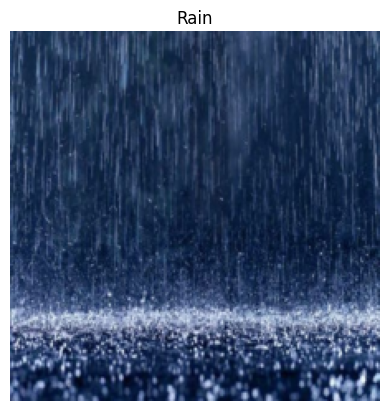

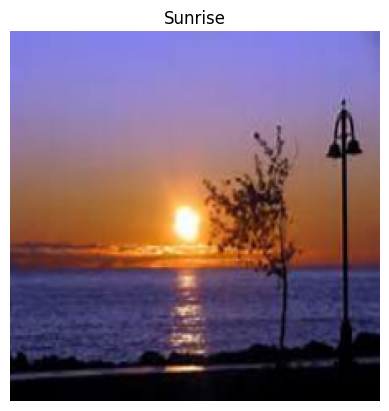

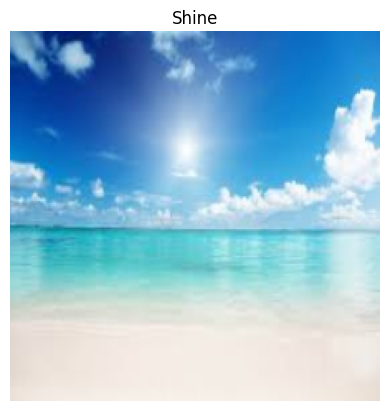

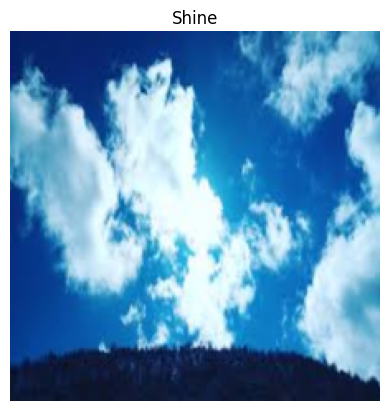

Test image Examples:


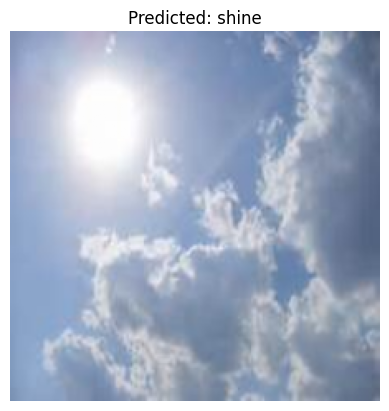

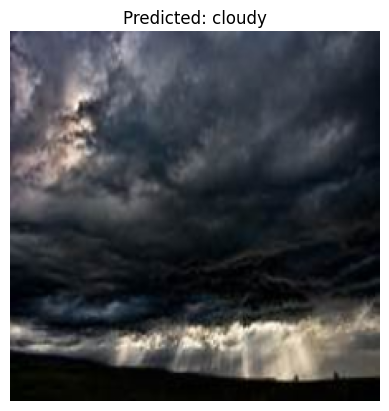

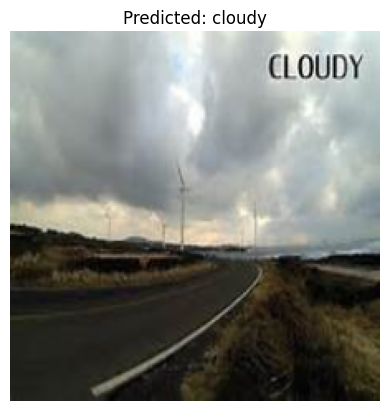

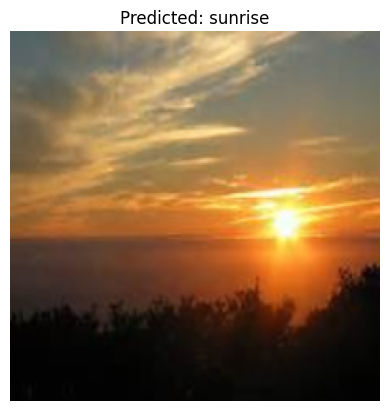

In [7]:
# Display a few images to verify
def imshow(img, title):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Visualize some training images
class_names = train_dataset.dataset.classes
dataiter = iter(train_loader)
images, labels = next(dataiter)

print("Training image Examples:")
for i in range(4):  # Show 4 training images
    imshow(images[i], title=class_names[labels[i]])

# Define class names
class_names = ['cloudy', 'rain', 'shine', 'sunrise']

# Visualize some test images
testiter = iter(test_loader)
test_images, test_labels = next(testiter)

print("Test image Examples:")
for i in range(4):
    imshow(test_images[i], title=f"Predicted: {class_names[test_labels[i]]}")

# **Functions Definitions:**

## **1) Plot Function:**

we defined the next function to plot the validation and accuracy later .




In [8]:
import matplotlib.pyplot as plt

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    # Plot Loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()


## **2) Loss Function :**

we choose to use the  next **Focal Loss** function we learned in class : <br>


$$
\mathcal{L}_{FL} = - \sum_{i=1}^{N} \alpha \cdot (1 - p_{t,i})^{\gamma} \cdot \log(p_{t,i})
$$

$
\text{Where:}
$


$
\begin{aligned}
&N \text{  is the number of training samples.} \\
&p_{t,i} \text{  is the predicted probability for the true class of the } i \text{-th sample.  } \\
&\alpha \text{  is a balancing factor for class imbalance.}\\
&\gamma \text{  is the focusing parameter that controls the down-weighting of easy examples.}\\
&\log(p_{t,i}) \text{  is the standard log loss component.}
\end{aligned}
$


<br> <br>

we choose this Loss function , due to its capability of not relying on class weights of distribution as also it penalize the incorrect perditions more improving the model adjustment. <br>
Also , because  some examples are harder to classify such as rainy and cloudy so using the Focall loss and increasing γ educes the loss for well-classified examples and focuses on misclassified ones.<br>

Another option is to use the label smoothing which also gave us pretty much same accuracies more or less and thats due to  its ability to generalize better and softens the penalty for misclassifications making the model robust to label Noise.

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class MyLossFunction(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        """
        Custom Focal Loss Function.

        Args:
            gamma (float): Focusing parameter (default=2.0).
            reduction (str): Reduction method: 'mean' or 'sum'.
        """
        super(MyLossFunction, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        Forward pass for Focal Loss.

        Args:
            inputs (Tensor): Model predictions (logits).
            targets (Tensor): Ground truth labels.

        Returns:
            Tensor: Computed focal loss.
        """
        # Apply softmax to get probabilities
        probs = F.softmax(inputs, dim=1)

        # Get the probabilities of the correct classes
        targets_one_hot = F.one_hot(targets, num_classes=inputs.size(1)).float()
        pt = (probs * targets_one_hot).sum(dim=1)

        # Compute focal loss
        focal_loss = -((1 - pt) ** self.gamma) * torch.log(pt + 1e-9)

        # Apply reduction
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

## **Training the model:**

We choose to use the pre trained model : **Resnet 18**

Because , as we learned in tutorial , Rensets are preferable than simple CNN for tasks where depper networks are required such as out homework task : image classifiaction .

We start by loading the pre-trained model Resnet 18 from pytroch .  and , in order to adapt it to our 4 weather classes classification we modify the fully connected layer of the model to outputs 4 classes , instead of its orignal output : 1000 classes.



We will train the model we choosed for 10 epochs with the next parametrs:


1.   Loss function :  MyLossFunction (Focal Loss ) with gamma =2 .
2.   Optimzer : Adam .
3. Hyperparameters:<br>

  learining rate : 0.001.<br>
  Batch size: 32.<br>
  Epochs:10.<br>




In [17]:


model = models.resnet18(pretrained=True)

#adapt the model to our needs output 4 classes (sun,cloud,....)
num_features = model.fc.in_features  # Get the number of input features to the FC layer
model.fc = nn.Linear(num_features, 4)  # Replace the FC layer with 4 outputs

# Step 3: Define loss function and optimizer
# Initialize the Focal Loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = MyLossFunction(gamma=2.0).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Step 4: Fine-tune the model
model = model.to(device)

# Training function
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total
        val_loss = val_running_loss / len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Train Loss: {train_loss:.3f}, Train Accuracy: {train_accuracy:.2f}% | "
              f"Val Loss: {val_loss:.3f}, Val Accuracy: {val_accuracy:.2f}%")

    return model, train_losses, val_losses, train_accuracies, val_accuracies


# Step 5: Train and Validate the Model
# Assuming `train_loader` and `val_loader` are defined
# Train the model and collect metrics
trained_model, train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, criterion, optimizer, train_loader, val_loader, num_epochs=10
)



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10, Train Loss: 0.277, Train Accuracy: 84.86% | Val Loss: 0.560, Val Accuracy: 86.85%
Epoch 2/10, Train Loss: 0.137, Train Accuracy: 88.62% | Val Loss: 0.084, Val Accuracy: 93.43%
Epoch 3/10, Train Loss: 0.108, Train Accuracy: 92.84% | Val Loss: 0.143, Val Accuracy: 89.67%
Epoch 4/10, Train Loss: 0.058, Train Accuracy: 94.95% | Val Loss: 0.137, Val Accuracy: 91.55%
Epoch 5/10, Train Loss: 0.048, Train Accuracy: 95.07% | Val Loss: 0.040, Val Accuracy: 95.77%
Epoch 6/10, Train Loss: 0.039, Train Accuracy: 95.31% | Val Loss: 0.037, Val Accuracy: 95.31%
Epoch 7/10, Train Loss: 0.039, Train Accuracy: 96.60% | Val Loss: 0.402, Val Accuracy: 87.32%
Epoch 8/10, Train Loss: 0.054, Train Accuracy: 95.54% | Val Loss: 0.116, Val Accuracy: 92.02%
Epoch 9/10, Train Loss: 0.034, Train Accuracy: 95.77% | Val Loss: 0.086, Val Accuracy: 94.84%
Epoch 10/10, Train Loss: 0.021, Train Accuracy: 98.00% | Val Loss: 0.078, Val Accuracy: 96.71%


# **Plot the losses and accuracy :**

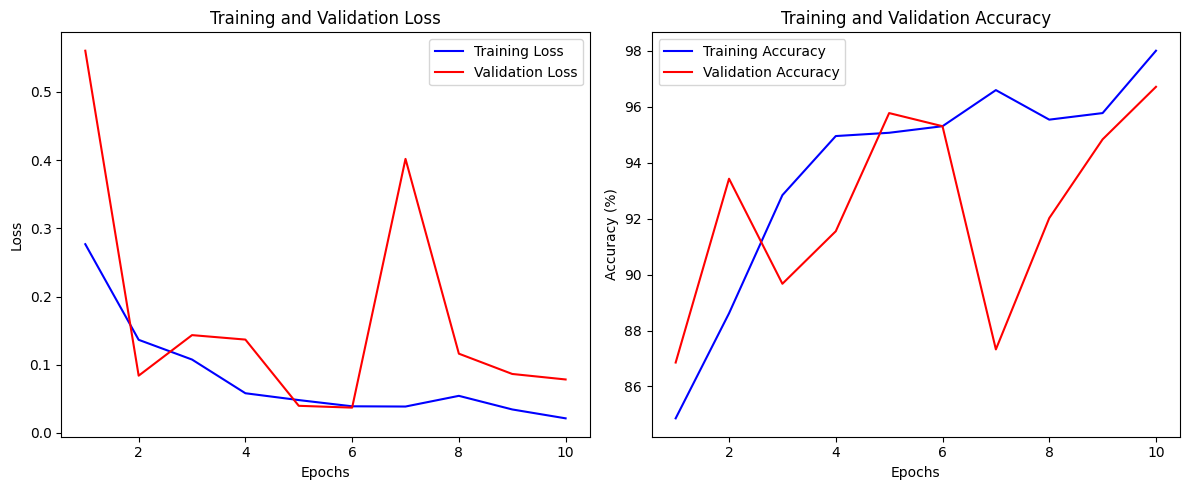

In [18]:
# Plot training history
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

## Results Explanation :

we can see from the training and validation results a steady decrease in training loss over the epochs , which reflect the model's ability to learn from the data .

During the first few epochs, both training and validation losses drop sharply as the model captures key features.
By epoch 7 , we observe a drop in validation accuracy which indicate the model may overfitted the data and that's due to the focal loss forces the model to focus on difficult examples which may reduce accuracy .

But , in later epochs , both training and validation losses  converge to lower values , with the validation accuracy improving which indicates the model's ability to generalize well to unseen data.



# MODEL - SUMMARY :

In [19]:
# Print the network summary
print(model)

# Function to calculate the number of trainable parameters
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate the number of trainable parameters
total_params = count_trainable_parameters(model)

print(f'Total trainable parameters: {total_params}')

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# **Evaluating the Model On Test Set :**

In order to evaluate the model we trained on the Testset :


*   We  will choose 5 images from the Testset and show it with their original label and with the predicted label .
*    We will print the Confusion matrix .

# Note :
From the result we got below we can see that the test accuracy is pretty high **(98.33%)** and the hard classification such as rainy and cloudy were pretty much well classified.




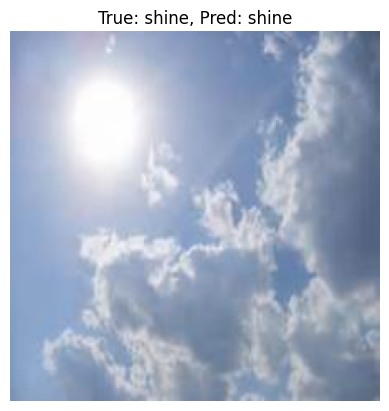

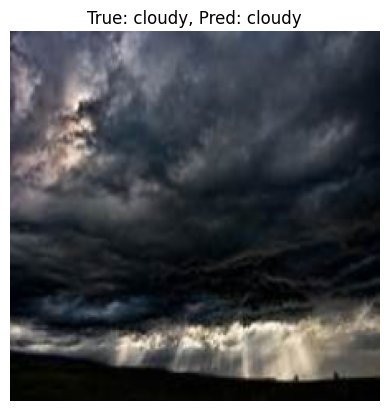

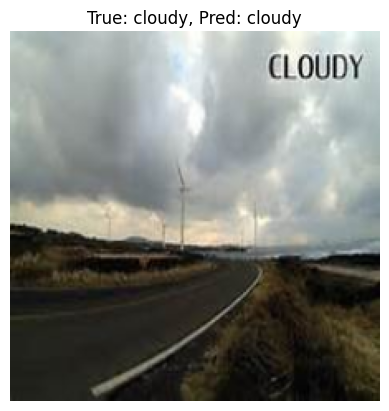

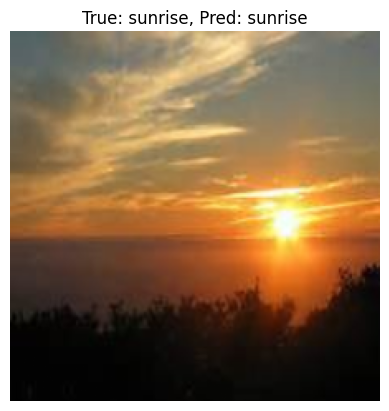

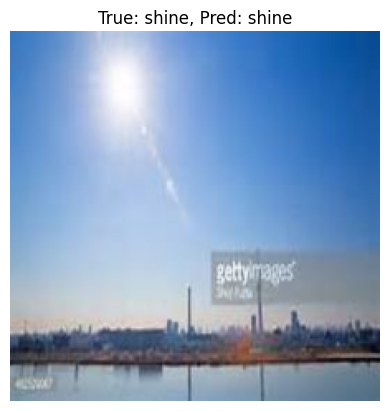


Test Accuracy: 98.33%


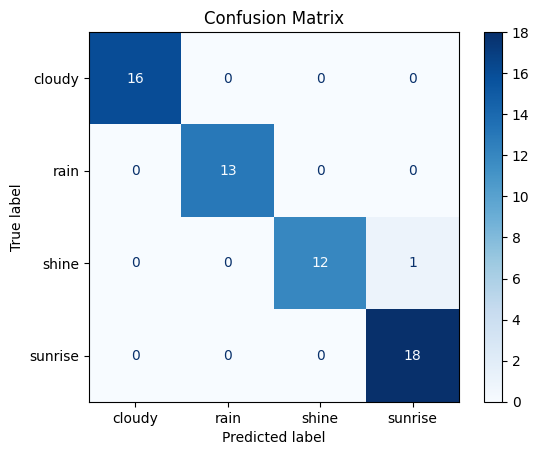

In [20]:

# Step 6: Evaluate on Test Data
# Updated evaluation function to show images with predictions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_and_visualize(model, test_loader, class_names, num_images=5):
    model.eval()
    correct = 0
    total = 0
    displayed = 0  # Counter for how many images have been shown

    all_preds = []   # To store all predictions
    all_labels = []  # To store all true labels

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # Collect predictions for confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Visualize a few predictions
            for i in range(inputs.size(0)):
                if displayed < num_images:
                    true_label = class_names[labels[i]]
                    predicted_label = class_names[predicted[i]]
                    title = f'True: {true_label}, Pred: {predicted_label}'
                    imshow(inputs[i].cpu(), title=title)
                    displayed += 1
                else:
                    break

    # Calculate and print overall accuracy
    print(f"\nTest Accuracy: {100 * correct / total:.2f}%")

    # Compute the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot the confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

# Evaluate
# Define class names (should match your dataset)
class_names = ['cloudy', 'rain', 'shine', 'sunrise']

# Evaluate and visualize predictions
evaluate_and_visualize(trained_model, test_loader, class_names, num_images=5)


# **Visualize the Model classification On 2D plane:**

in order to visualize how the model classified the data on a 2D plane we will use the T-SNE projection algorithm we learned in the class to reduce the dimensions of the classes to 2D to visualize it.

we can see from the plot  we got that the model success well in generalization and classification.


## Define Extract Feature Function:

In [21]:

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
# Function to extract features from the model
def extract_features(model, data_loader):
    model.eval()
    features = []
    labels_list = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Extract features (before the final fully connected layer)
            feature_vector = outputs.cpu().numpy()
            features.append(feature_vector)
            labels_list.extend(labels.cpu().numpy())

    features = np.concatenate(features, axis=0)
    return features, np.array(labels_list)


## Plot T-SNE :

In [22]:
# Function to plot t-SNE
def plot_tsne(features, labels, class_names):
    # Apply t-SNE to reduce features to 2D
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
    reduced_features = tsne.fit_transform(features)

    # Plot the t-SNE results
    plt.figure(figsize=(10, 8))
    for class_idx, class_name in enumerate(class_names):
        indices = labels == class_idx
        plt.scatter(reduced_features[indices, 0],
                    reduced_features[indices, 1],
                    label=class_name,
                    alpha=0.6)

    plt.legend()
    plt.title("t-SNE Visualization of Model Features")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True)
    plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


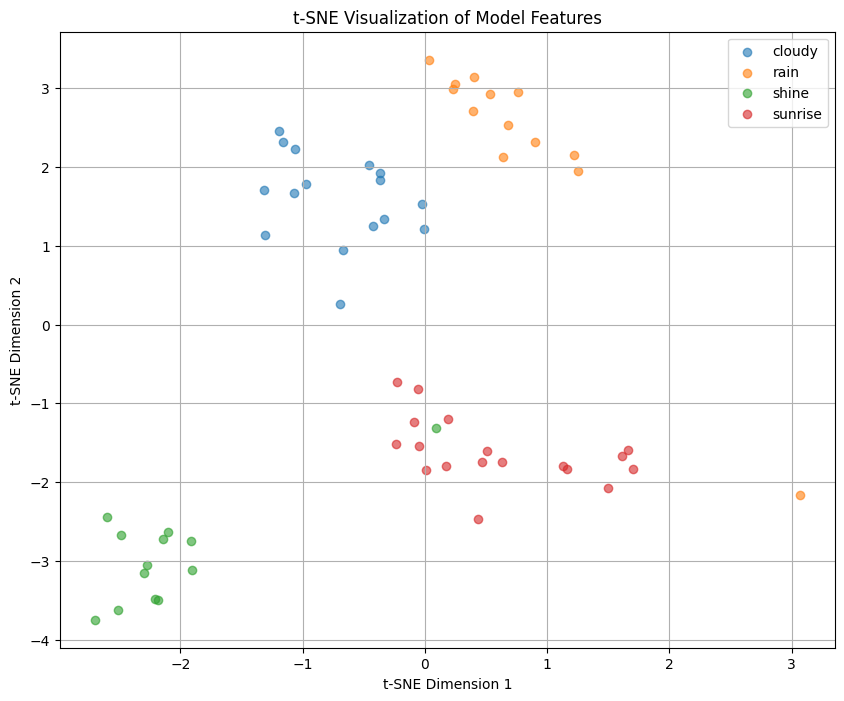

In [23]:
# Extract features from the test set
features, labels = extract_features(trained_model, test_loader)

# Plot t-SNE visualization
plot_tsne(features, labels, class_names)
